In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Setup paths (basato sul tuo script precedente)
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

c:\Users\cola0\anaconda3\envs\nlp-project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\cola0\Desktop\nlp.project-colangelo-2526
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints


In [2]:
# === Checkpoint paths ===
# Teacher fine-tuned
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"

# IMPORTANT:
# Per la fase 1 NON usare 'student_base_final' (salva solo il backbone HF).
# Devi usare un checkpoint del Trainer (checkpoint-xxxxx) che contiene anche i pesi di 'fit_dense'.
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-57856"  # <-- ultimo checkpoint
student_core_path = CKPT_DIR / "tinybert_phase1" / "student_base_final"

# (Opzionale) student fase 2, se vuoi confrontare anche quello
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

print("Teacher:", teacher_path)
print("Phase1 ckpt (con fit_dense):", phase1_ckpt_path)
print("Student phase2 (opzionale):", student_phase2_path)

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"


Teacher: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
Phase1 ckpt (con fit_dense): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856
Student phase2 (opzionale): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


AssertionError: Non esiste: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000

## Plot 3: PCA only

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device).eval()

# core HF (student backbone) dal checkpoint fase 1
student_core = AutoModelForSequenceClassification.from_pretrained(phase1_ckpt_path).to(device).eval()


Device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856 and are newly initialized: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert

In [ ]:
import torch
from safetensors.torch import load_file
from transformers import AutoModelForSequenceClassification
from distillation import TinyBERTPhase1

device = "cuda" if torch.cuda.is_available() else "cpu"

# path
#student_core_path = "checkpoints/tinybert_phase1/student_base_final"     # ha config 312
#phase1_ckpt_path   = "checkpoints/tinybert_phase1/checkpoint-57856"      # ha wrapper weights incl fit_dense

# 1) Crea core corretto (hidden_size=312)
student_core = AutoModelForSequenceClassification.from_pretrained(student_core_path).to(device).eval()

# 2) Wrappa
student = TinyBERTPhase1(student_core).to(device).eval()

# 3) Carica state dict del trainer checkpoint, ma:
#    - dentro ci sono chiavi "student.*" e "fit_dense.*"
sd = load_file(f"{phase1_ckpt_path}/model.safetensors")

# 4) Carica direttamente: deve andare senza mismatch ora
missing, unexpected = student.load_state_dict(sd, strict=False)

print("Missing fit_dense keys:", [k for k in missing if "fit_dense" in k])
print("Unexpected keys (sample):", unexpected[:15])

Missing fit_dense keys: []
Unexpected keys (sample): []


In [ ]:
mapping = [0, 3, 6, 9, 12]
student_last_idx = 4
teacher_last_idx = 12

def mean_pool(hidden, attention_mask):
    # hidden: [1,L,H], attention_mask: [1,L]
    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)  # [1,L,1]
    summed = (hidden * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1.0)
    return summed / denom  # [1,H]

@torch.no_grad()
def collect_reps(test_ds, n_samples=2000, seed=0, pooling="mean"):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)

    T_vecs, S_vecs, y = [], [], []

    for i in idx:
        ex = test_ds[i]
        input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
        attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
        token_type_ids = torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device) if "token_type_ids" in ex else None

        t_out = teacher(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_hidden_states=True,
            return_dict=True
        )
        s_out = student(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # teacher hidden: len=13, idx 12 = last layer
        t_h = t_out.hidden_states[teacher_last_idx]  # [1,L,768]

        # student hidden: len=5, idx 4 = last layer (312) -> proiezione in 768 con fit_dense addestrata
        s_h = s_out.hidden_states[student_last_idx]              # [1,L,312]
        s_proj = student.fit_dense[student_last_idx](s_h)        # [1,L,768]

        if pooling == "cls":
            t_vec = t_h[:, 0, :]
            s_vec = s_proj[:, 0, :]
        elif pooling == "mean":
            t_vec = mean_pool(t_h, attention_mask)
            s_vec = mean_pool(s_proj, attention_mask)
        else:
            raise ValueError("pooling deve essere 'cls' oppure 'mean'")

        T_vecs.append(t_vec.squeeze(0).cpu().numpy())
        S_vecs.append(s_vec.squeeze(0).cpu().numpy())
        y.append(int(ex["label"]))

    return np.vstack(T_vecs), np.vstack(S_vecs), np.array(y)

# Carico test set
from datasets import concatenate_datasets

test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

N_PER_CLASS = 2000
SEED = 42

ds0 = test_ds.filter(lambda x: x["label"] == 0).shuffle(seed=SEED).select(range(N_PER_CLASS))
ds1 = test_ds.filter(lambda x: x["label"] == 1).shuffle(seed=SEED).select(range(N_PER_CLASS))

test_balanced = concatenate_datasets([ds0, ds1]).shuffle(seed=SEED)
print(test_balanced, test_balanced.features)
# Consigliato: mean pooling (più stabile di CLS per confronti di alignment)
T, S, y = collect_reps(test_balanced, n_samples=2000, pooling="mean")


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Dataset({
    features: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids'],
    num_rows: 4000
}) {'review_id': Value('int64'), 'movie_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int64')), 'attention_mask': List(Value('int64')), 'token_type_ids': List(Value('int64'))}


In [ ]:
# === PCA 3D in "teacher space" ===
# Fit scaler + PCA SOLO sul teacher, poi proietta anche lo student nello stesso spazio.

scaler = StandardScaler().fit(T)
Tz = scaler.transform(T)
Sz = scaler.transform(S)

pca = PCA(n_components=3, random_state=0)
pca.fit(Tz)          # <-- fit solo teacher
T3 = pca.transform(Tz)
S3 = pca.transform(Sz)


In [ ]:
def cosine(a, b, eps=1e-9):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return (a * b).sum(axis=1)

cos_sim = cosine(S, T)

print("Mean cosine (No-spoiler):", float(cos_sim[y==0].mean()), "±", float(cos_sim[y==0].std()))
print("Mean cosine (Spoiler):   ", float(cos_sim[y==1].mean()), "±", float(cos_sim[y==1].std()))


Mean cosine (No-spoiler): 0.9633855223655701 ± 0.01879744790494442
Mean cosine (Spoiler):    0.9599721431732178 ± 0.02459251694381237


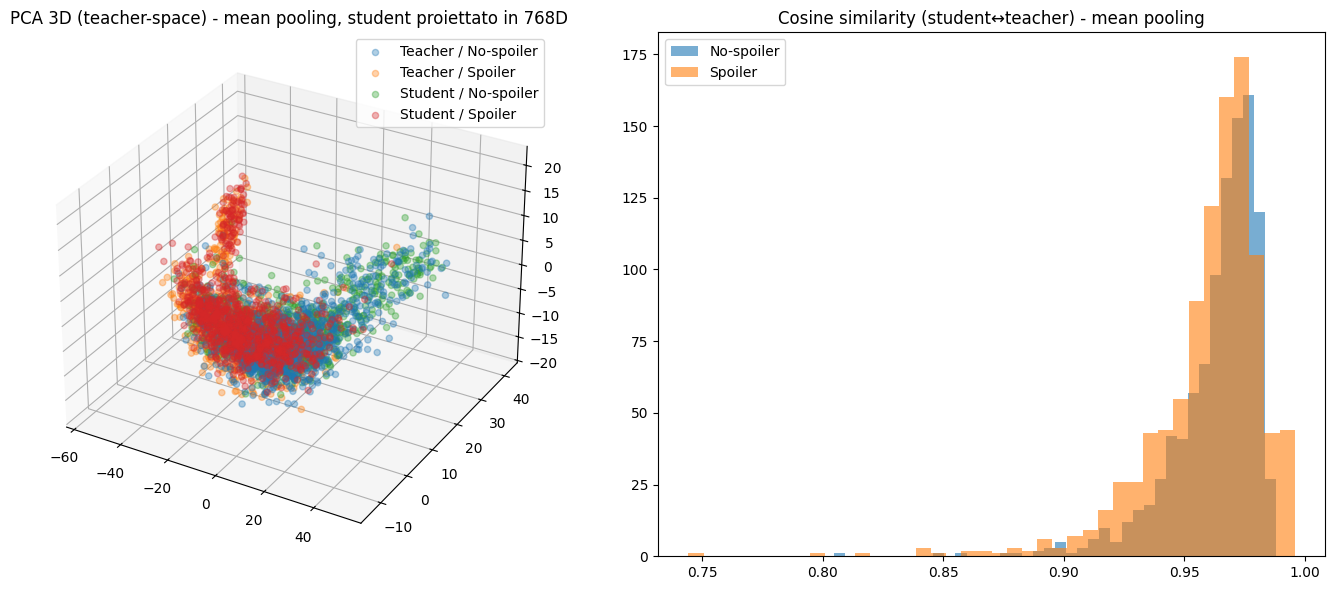

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121, projection="3d")
# Teacher
ax.scatter(T3[y==0,0], T3[y==0,1], T3[y==0,2], marker="o", alpha=0.35, label="Teacher / No-spoiler")
ax.scatter(T3[y==1,0], T3[y==1,1], T3[y==1,2], marker="o", alpha=0.35, label="Teacher / Spoiler")
# Student
ax.scatter(S3[y==0,0], S3[y==0,1], S3[y==0,2], marker="o", alpha=0.35, label="Student / No-spoiler")
ax.scatter(S3[y==1,0], S3[y==1,1], S3[y==1,2], marker="o", alpha=0.35, label="Student / Spoiler")

ax.set_title("PCA 3D (teacher-space) - mean pooling, student proiettato in 768D")
ax.legend(loc="best")

ax2 = fig.add_subplot(122)
ax2.hist(cos_sim[y==0], bins=40, alpha=0.6, label="No-spoiler")
ax2.hist(cos_sim[y==1], bins=40, alpha=0.6, label="Spoiler")
ax2.set_title("Cosine similarity (student↔teacher) - mean pooling")
ax2.legend()

plt.tight_layout()
plt.show()


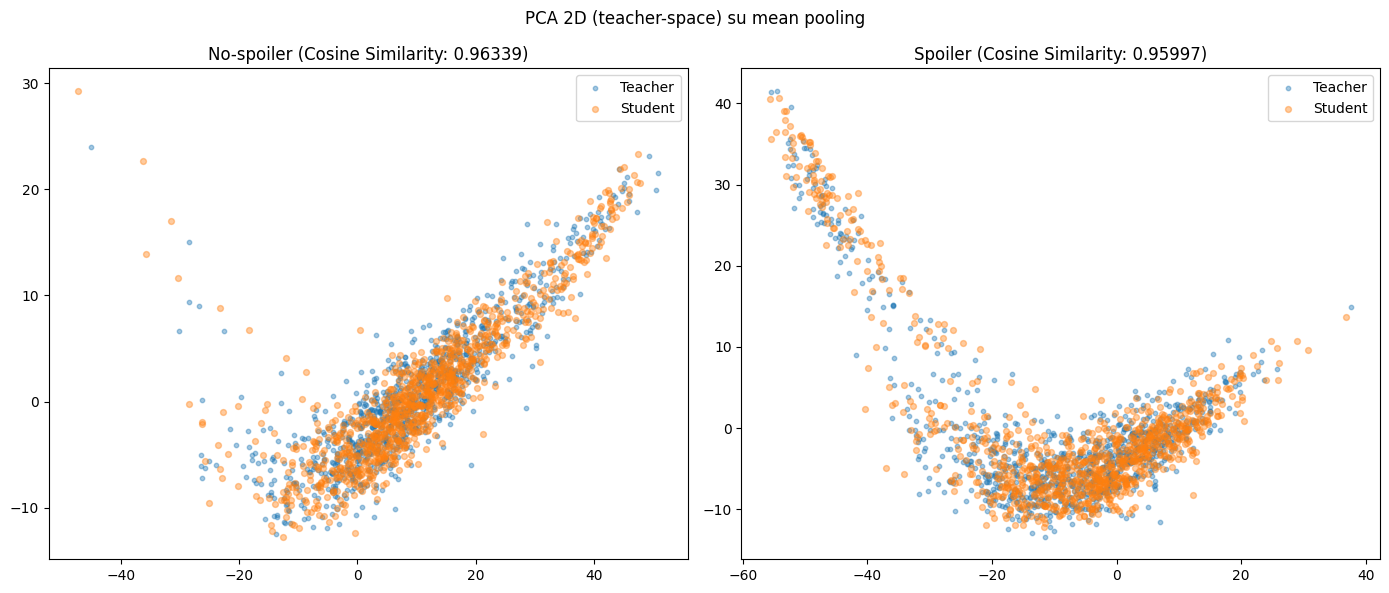

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X teacher-space già costruito: T (N,768), S (N,768), y (N,)
# PCA fit sul teacher
Tz = StandardScaler().fit_transform(T)
pca = PCA(n_components=2, random_state=0).fit(Tz)

T2 = pca.transform(Tz)
S2 = pca.transform(StandardScaler().fit_transform(S))  # meglio: usa lo stesso scaler del teacher!
# -> versione corretta:
scaler = StandardScaler().fit(T)
T2 = pca.fit_transform(scaler.transform(T))
S2 = pca.transform(scaler.transform(S))

ev = pca.explained_variance_ratio_.sum()

fig, axs = plt.subplots(1,2, figsize=(14,6))

for cls, ax in [(0, axs[0]), (1, axs[1])]:
    ax.scatter(T2[y==cls,0], T2[y==cls,1], s=10, alpha=0.4, label="Teacher")
    ax.scatter(S2[y==cls,0], S2[y==cls,1], s=18, alpha=0.4, label="Student")
    ax.set_title((f"No-spoiler (Cosine Similarity: {cos_sim[y==0].mean():.5})" if cls==0 else f"Spoiler (Cosine Similarity: {cos_sim[y==1].mean():.5})"))
    ax.legend()

fig.suptitle(f"PCA 2D (teacher-space) su mean pooling")
plt.tight_layout()
plt.show()
plt.savefig('pca_embeddings.png')

In [ ]:
text = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay."

enc = tokenizer(
    text, 
    add_special_tokens=True, 
    truncation=True,
    max_length =512,
    return_tensors = "pt"
    )
#print("n_subword_tokens =", len(enc["input_ids"]))

enc = {k: v.to(device) for k,v in enc.items()}
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
L = len(tokens)

In [ ]:
@torch.no_grad()
def get_attn(model, enc, layer_idx):
    out = model(**enc, output_attentions=True, return_dict=True)
    # HF di solito restituisce già attenzione post-softmax: [B, heads, L, L]
    A = out.attentions[layer_idx][0]          # [heads, L, L]
    A = A.detach().float().cpu().numpy()
    return A

In [ ]:
t_layer = 11   # teacher last
s_layer = 3    # student last

A_T = get_attn(teacher, enc, t_layer)         # [hT, L, L]
A_S = get_attn(student, enc, s_layer)   # [hS, L, L]

M_T = A_T.mean(axis=0)  # [L,L]
M_S = A_S.mean(axis=0)

In [ ]:
target = "dies"
idxs = [i for i,tok in enumerate(tokens) if tok == target]
if len(idxs) == 0:
    # fallback: cerca sottostringa (per casi wordpiece)
    idxs = [i for i,tok in enumerate(tokens) if target in tok]

center = idxs[0] if idxs else min(20, L//2)
W = 25
a = max(0, center - W)
b = min(L, center + W + 1)

sub_tokens = tokens[a:b]
sub_T = M_T[a:b, a:b]
sub_S = M_S[a:b, a:b]

In [ ]:
def flat_cos(X, Y, eps=1e-9):
    x = X.reshape(-1); y = Y.reshape(-1)
    return float((x @ y) / ((np.linalg.norm(x)+eps)*(np.linalg.norm(y)+eps)))

cos = flat_cos(sub_S, sub_T)
mse = float(((sub_S - sub_T)**2).mean())
print(cos, mse)

0.9240966439247131 3.880975054926239e-05


In [ ]:
k = 10
rowT = M_T[center]
rowS = M_S[center]
topT = np.argsort(-rowT)[:k]
topS = np.argsort(-rowS)[:k]
overlap = len(set(topT.tolist()) & set(topS.tolist()))

top = np.argsort(-rowT)[:10]
print([(tokens[i], float(rowT[i])) for i in top])

[('.', 0.05079394578933716), ('.', 0.050793033093214035), ('.', 0.05057419463992119), ('.', 0.05052806809544563), ('.', 0.049713630229234695), ('.', 0.04953746870160103), ('.', 0.04842096567153931), ('.', 0.04804930090904236), ('.', 0.0471438430249691), ('.', 0.0402819886803627)]


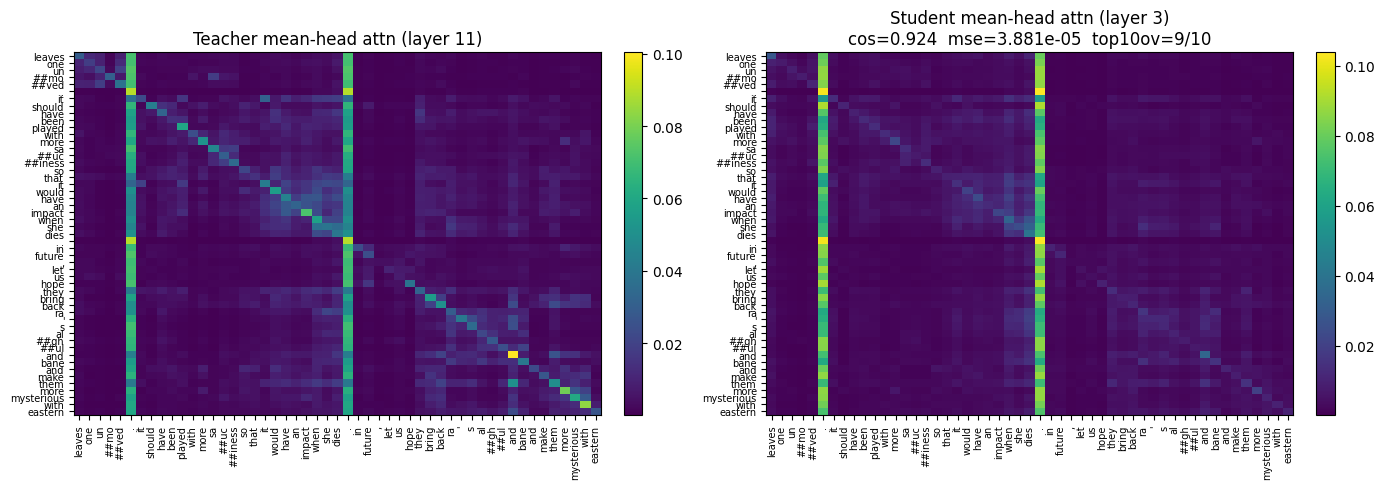

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(sub_T, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Teacher mean-head attn (layer {t_layer})")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.imshow(sub_S, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Student mean-head attn (layer {s_layer})\ncos={cos:.3f}  mse={mse:.4g}  top{k}ov={overlap}/{k}")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
plt.savefig('attn_heatmaps.png')

In [ ]:
%pip install transformers_interpret
from transformers_interpret import SequenceClassificationExplainer

# Usa il tuo tokenizer e i modelli già caricati nel notebook
teacher_explainer = SequenceClassificationExplainer(teacher, tokenizer)
student_explainer = SequenceClassificationExplainer(student_core, tokenizer)


# Calcola le attribuzioni
teacher_attributions = teacher_explainer(text)
student_attributions = student_explainer(text)

# La libreria ha un metodo integrato per visualizzare l'output in HTML nel notebook
teacher_explainer.visualize("teacher_saliency.html")
student_explainer.visualize("student_saliency.html")

   ---------------------------------------- 0.0/793.8 kB ? eta -:--:--
   ---------------------------------------- 793.8/793.8 kB 17.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 36.8 MB/s  0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 15.8/15.8 MB 83.1 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.2.6

    Uninstalling numpy-2.2.6:

   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
      Successfully uninstalled numpy-2.2.6
   ------------- -------------------------- 2/6 [numpy]
   ------------- -

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

def get_mean_cls_entropy(model, test_ds, device, n_samples=500, seed=42):
    """
    Calcola l'entropia media dell'attenzione del token [CLS]
    sfruttando lo stesso stile di iterazione della tua funzione collect_reps.
    """
    model.eval()
    entropies = []
    
    rng = np.random.default_rng(seed)
    # Prendiamo un sottoinsieme per velocizzare (es. 500 o 1000 sample)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)
    
    with torch.no_grad():
        for i in idx:
            ex = test_ds[i]
            # Prepariamo i tensori esattamente come fai nel tuo notebook
            input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
            attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
            token_type_ids = torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device) if "token_type_ids" in ex else None
            
            # Forward pass richiedendo esplicitamente le attention maps
            outputs = model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                token_type_ids=token_type_ids,
                output_attentions=True,
                return_dict=True
            )
            
            # outputs.attentions è una tupla contenente l'attenzione per ogni layer.
            # Prendiamo l'ultimo layer: [-1]
            last_layer_attn = outputs.attentions[-1] 
            
            # last_layer_attn shape: [1, num_heads, seq_len, seq_len]
            # Facciamo la media sulle attention heads -> shape: [1, seq_len, seq_len]
            mean_heads = last_layer_attn.mean(dim=1)
            
            # Estraiamo l'attenzione del token [CLS] (indice 0) verso tutti gli altri token.
            # shape -> [seq_len]
            cls_attn = mean_heads[0, 0, :]
            
            # Filtriamo i token di padding: ci interessano solo i token effettivi della recensione
            valid_len = attention_mask[0].sum().item()
            valid_attn = cls_attn[:valid_len].cpu().numpy()
            
            # Calcoliamo l'entropia di Shannon (in base e) sulla distribuzione di attenzione
            ent = scipy.stats.entropy(valid_attn)
            entropies.append(ent)
                
    return np.mean(entropies), np.std(entropies)

Entropia Media Teacher: 4.532 ± 0.537
Entropia Media Student: 4.510 ± 0.506


C:\Users\cola0\AppData\Local\Temp\ipykernel_4200\2860603780.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


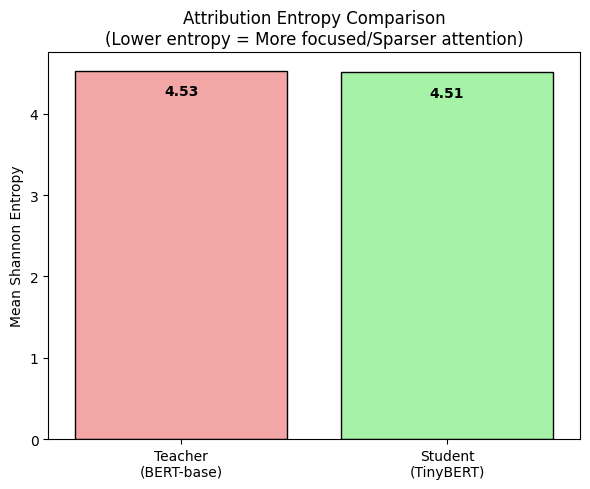

In [ ]:
# Usa il dataset test_balanced che hai già preparato nel notebook
# Usa n_samples=500 o 1000 per calcolarlo in pochi secondi
mean_ent_teacher, std_ent_teacher = get_mean_cls_entropy(teacher, test_balanced, device, n_samples=1000)
mean_ent_student, std_ent_student = get_mean_cls_entropy(student_core, test_balanced, device, n_samples=1000)

print(f"Entropia Media Teacher: {mean_ent_teacher:.3f} ± {std_ent_teacher:.3f}")
print(f"Entropia Media Student: {mean_ent_student:.3f} ± {std_ent_student:.3f}")

# Generazione del grafico (il tuo "Mic Drop" per la presentazione)
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=['Teacher\n(BERT-base)', 'Student\n(TinyBERT)'], 
    y=[mean_ent_teacher, mean_ent_student],
    palette=['#FF9999', '#99FF99'],
    edgecolor='black'
)

# Aggiungiamo il testo del valore esatto sulle barre per maggior chiarezza
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, -15), textcoords = 'offset points',
                color='black', fontweight='bold')

plt.title("Attribution Entropy Comparison\n(Lower entropy = More focused/Sparser attention)")
plt.ylabel("Mean Shannon Entropy")
plt.tight_layout()
plt.show()

In [ ]:
# === Load final distilled student for interpretability ===
# Per la faithfulness analysis conviene confrontare il teacher fine-tuned
# con lo student finale (phase 2), non con lo student di phase 1 usato per l'alignment.

use_final_student = student_phase2_path.exists()

if use_final_student:
    student_faith = AutoModelForSequenceClassification.from_pretrained(student_phase2_path).to(device).eval()
    print(f"Using final distilled student from: {student_phase2_path}")
else:
    student_faith = student_core.to(device).eval()
    print("WARNING: student_phase2 checkpoint not found. Falling back to current student_core.")